# The Epinions Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
import seaborn as sns
import networkx as nx

plt.style.use('classic')
sns.set()

In [34]:
# Load trust matrix
trust_mat = loadmat('/kaggle/input/epinions/epinion_trust_with_timestamp.mat')['trust']
trust_df = pd.DataFrame(trust_mat, columns=['user', 'trusted_user', 'timestamp'])
# Load rating matrix
rating_mat = loadmat('/kaggle/input/epinions/rating_with_timestamp.mat')['rating']
rating_df = pd.DataFrame(rating_mat, 
                         columns=['user', 'product', 'category', 'rating', 'helpfulness', 'timestamp'])

trust_df.head(), rating_df.head()

(   user  trusted_user  timestamp
 0  3722          7641         11
 1  3722          1646         11
 2  3722          2791         11
 3  3722          6057         11
 4  3722          3244         11,
    user  product  category  rating  helpfulness  timestamp
 0     1        1         3       2            2          1
 1     1        2         2       2            3          1
 2     1        3         3       2            1          1
 3     1        4         3       5            2          1
 4     1        5         3       3            2          1)

In [35]:
print("Ratings shape:", rating_df.shape)
print("Trust edges shape:", trust_df.shape)

print("\nUnique users in ratings:", rating_df['user'].nunique())
print("Unique users in trust:", trust_df['user'].nunique())
print("Unique items:", rating_df['product'].nunique())

print("\nTimestamps range (ratings):", rating_df['timestamp'].min(), "→", rating_df['timestamp'].max())
print("Timestamps range (trust):", trust_df['timestamp'].min(), "→", trust_df['timestamp'].max())

Ratings shape: (922267, 6)
Trust edges shape: (300548, 3)

Unique users in ratings: 22164
Unique users in trust: 8514
Unique items: 296277

Timestamps range (ratings): 1 → 11
Timestamps range (trust): 1 → 11


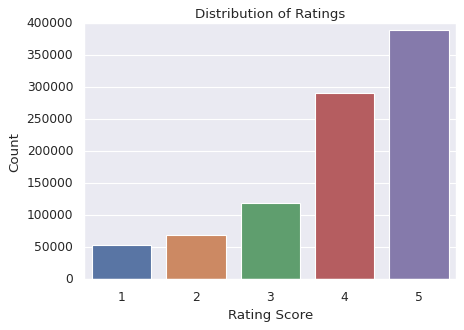

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x=rating_df['rating'])
plt.title("Distribution of Ratings")
plt.xlabel("Rating Score")
plt.ylabel("Count")
plt.show()

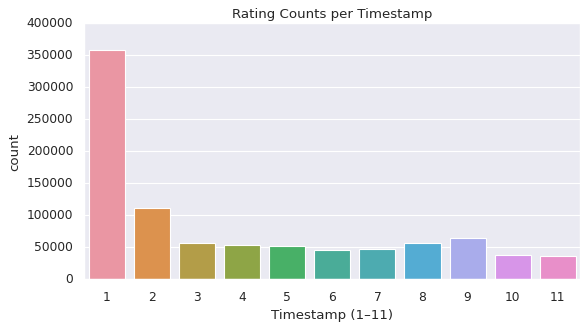

In [37]:
plt.figure(figsize=(8,4))
sns.countplot(x=rating_df['timestamp'])
plt.title("Rating Counts per Timestamp")
plt.xlabel("Timestamp (1–11)")
plt.show()

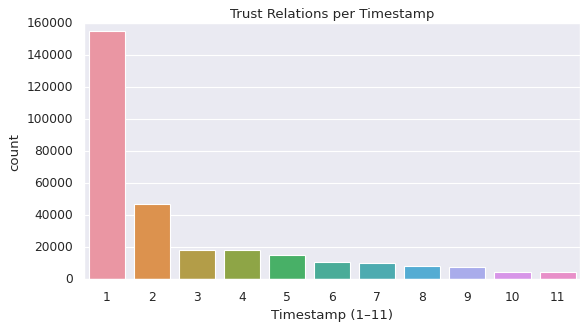

In [38]:
plt.figure(figsize=(8,4))
sns.countplot(x=trust_df['timestamp'])
plt.title("Trust Relations per Timestamp")
plt.xlabel("Timestamp (1–11)")
plt.show()

Nodes: 8518
Edges: 300091


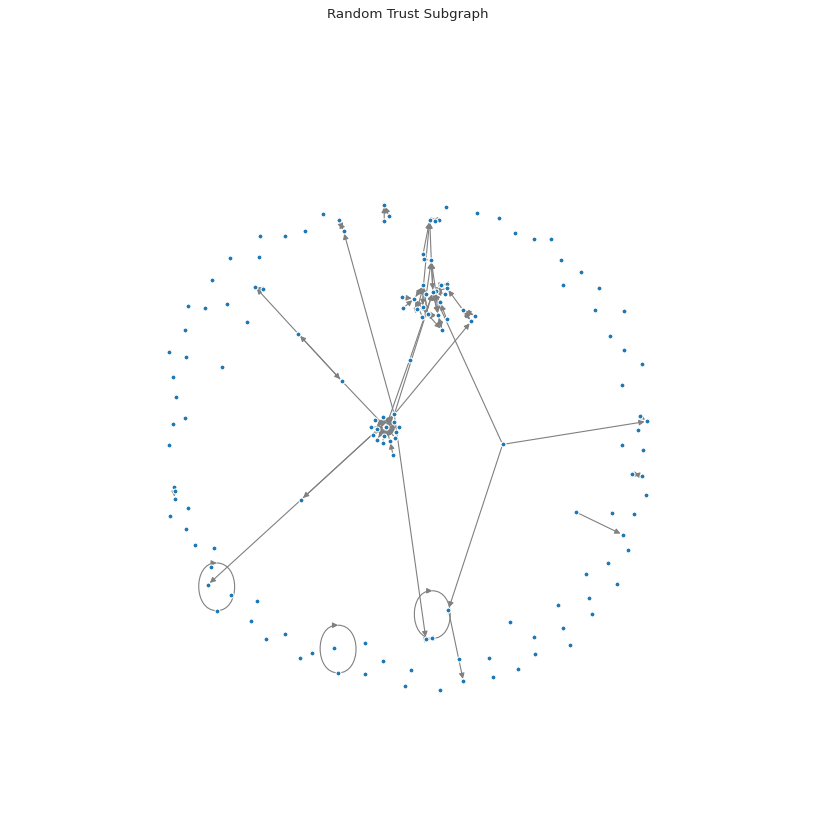

In [53]:
G = nx.DiGraph()
G.add_edges_from(trust_df[['user', 'trusted_user']].astype(int).values)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

sample_nodes = np.random.choice(list(G.nodes()), size=150, replace=False)
subgraph = G.subgraph(sample_nodes)

plt.figure(figsize=(10,10))
nx.draw(subgraph, node_size=20, edge_color="gray")
plt.title("User-User Social Subgraph")
plt.show()

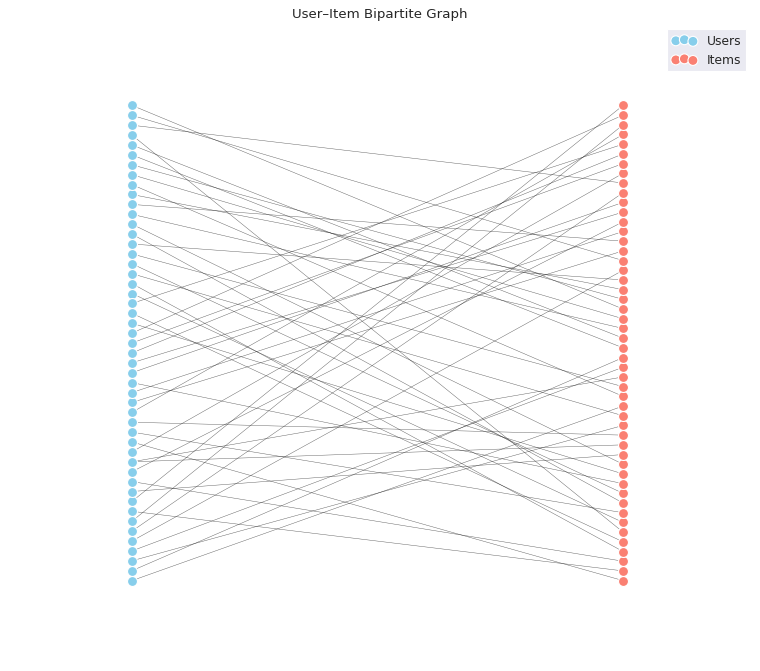

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

sample_size = 50   
sample = rating_df.sample(sample_size, random_state=42)
B = nx.Graph()

users = sample['user'].astype(int).unique()
items = sample['product'].astype(int).unique()

B.add_nodes_from(users, bipartite=0)
B.add_nodes_from(items, bipartite=1)
edges = list(zip(sample['user'].astype(int), sample['product'].astype(int)))
B.add_edges_from(edges)
plt.figure(figsize=(12, 10))

user_nodes = [n for n, d in B.nodes(data=True) if d['bipartite'] == 0]
item_nodes = list(set(B.nodes()) - set(user_nodes))

pos = nx.bipartite_layout(B, user_nodes)
nx.draw_networkx_nodes(B, pos, nodelist=user_nodes, 
                       node_color='skyblue', node_size=80, label='Users')
nx.draw_networkx_nodes(B, pos, nodelist=item_nodes, 
                       node_color='salmon', node_size=80, label='Items')
nx.draw_networkx_edges(B, pos, width=0.4, alpha=0.7)
plt.title("User–Item Bipartite Subgraph")
plt.axis('off')
plt.legend()
plt.show()

# Gloabal Mean Predictor with Biases Model

In [27]:

import numpy as np
from scipy.io import loadmat
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================
# 1. Load and preprocess data 
# =============================================================
percent = 1.0
batch_size = 4096

data = loadmat("/kaggle/input/epinions/rating_with_timestamp.mat")
rating = data['rating']

# percent subset if needed
if percent < 1.0:
    N = rating.shape[0]
    keep = int(N * percent)
    idx_keep = np.random.choice(N, keep, replace=False)
    rating = rating[idx_keep]

uids = rating[:, 0].astype(int) - 1
iids = rating[:, 1].astype(int) - 1
ratings = rating[:, 3].astype(float)
times = rating[:, 5].astype(int) - 1    # EXACT same timestamp column as TimeSVD++

n_users = uids.max() + 1
n_items = iids.max() + 1

print("Users:", n_users, "Items:", n_items)
print("Using %d samples" % len(rating))

# =============================================================
# 2. Temporal split 
# =============================================================
train_mask = (times <= 6)           # time bins 0–6 → original 1–7
val_mask   = (times == 7) | (times == 8)   # original 8–9
test_mask  = (times == 9) | (times == 10)  # original 10–11

X_train = np.column_stack([uids[train_mask], iids[train_mask]])
y_train = ratings[train_mask]

X_val = np.column_stack([uids[val_mask], iids[val_mask]])
y_val = ratings[val_mask]

X_test = np.column_stack([uids[test_mask], iids[test_mask]])
y_test = ratings[test_mask]

print("Train samples:", len(y_train))
print("Val samples  :", len(y_val))
print("Test samples :", len(y_test))


# =============================================================
# 3. Bias-Only Baseline Model
# =============================================================
class BiasOnlyBaseline:
    def __init__(self, n_users, n_items, lr=0.01, reg=0.01):
        self.lr = lr
        self.reg = reg
        self.n_users = n_users
        self.n_items = n_items
        
        self.mu = 0
        self.bu = np.zeros(n_users)
        self.bi = np.zeros(n_items)
    
    def predict(self, u, i):
        return self.mu + self.bu[u] + self.bi[i]

    def evaluate_rmse(self, X, y):
        preds = np.array([self.predict(u, i) for u, i in X])
        return np.sqrt(mean_squared_error(y, preds))

    def evaluate_mae(self, X, y):
        preds = np.array([self.predict(u, i) for u, i in X])
        return mean_absolute_error(y, preds)

    def fit(self, X_train, y_train, X_val, y_val, epochs=50, patience=5):
        self.mu = np.mean(y_train)
        best_val = float("inf")
        wait = 0

        for epoch in range(1, epochs + 1):
            idx = np.random.permutation(len(X_train))
            X_train_shuffled = X_train[idx]
            y_train_shuffled = y_train[idx]

            for (u, i), r in zip(X_train_shuffled, y_train_shuffled):
                pred = self.predict(u, i)
                err = r - pred
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])

            train_rmse = self.evaluate_rmse(X_train, y_train)
            val_rmse = self.evaluate_rmse(X_val, y_val)
            print(f"Epoch {epoch:02d}: Train RMSE = {train_rmse:.4f}, Val RMSE = {val_rmse:.4f}")

            if val_rmse < best_val:
                best_val = val_rmse
                wait = 0
                best_params = (self.mu, self.bu.copy(), self.bi.copy())
            else:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

        self.mu, self.bu, self.bi = best_params


# =============================================================
# 4. Train & Evaluate
# =============================================================
baseline = BiasOnlyBaseline(n_users=n_users, n_items=n_items, lr=0.01, reg=0.05)
baseline.fit(X_train, y_train, X_val, y_val, epochs=50, patience=5)

test_rmse = baseline.evaluate_rmse(X_test, y_test)
test_mae  = baseline.evaluate_mae(X_test, y_test)

print("\n================ FINAL TEST METRICS ================\n")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE : {test_mae:.4f}")


Users: 22166 Items: 296277
Using 922267 samples
Train samples: 727400
Val samples  : 121524
Test samples : 73343
Epoch 01: Train RMSE = 1.0707, Val RMSE = 1.0781
Epoch 02: Train RMSE = 1.0382, Val RMSE = 1.0719
Epoch 03: Train RMSE = 1.0186, Val RMSE = 1.0685
Epoch 04: Train RMSE = 1.0043, Val RMSE = 1.0659
Epoch 05: Train RMSE = 0.9931, Val RMSE = 1.0644
Epoch 06: Train RMSE = 0.9840, Val RMSE = 1.0626
Epoch 07: Train RMSE = 0.9761, Val RMSE = 1.0619
Epoch 08: Train RMSE = 0.9694, Val RMSE = 1.0616
Epoch 09: Train RMSE = 0.9633, Val RMSE = 1.0608
Epoch 10: Train RMSE = 0.9579, Val RMSE = 1.0602
Epoch 11: Train RMSE = 0.9530, Val RMSE = 1.0598
Epoch 12: Train RMSE = 0.9484, Val RMSE = 1.0591
Epoch 13: Train RMSE = 0.9442, Val RMSE = 1.0593
Epoch 14: Train RMSE = 0.9403, Val RMSE = 1.0586
Epoch 15: Train RMSE = 0.9365, Val RMSE = 1.0583
Epoch 16: Train RMSE = 0.9332, Val RMSE = 1.0587
Epoch 17: Train RMSE = 0.9299, Val RMSE = 1.0579
Epoch 18: Train RMSE = 0.9268, Val RMSE = 1.0580
Epoch

# Naive GraphRec Model

In [17]:
# SECTION 1 — Imports & Utilities

import os
import random
from collections import defaultdict
from typing import List, Tuple

import numpy as np
from scipy.io import loadmat
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import networkx as nx

# -------------------------
# Utilities
# -------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def rmse_mae(preds, labels):
    preds = np.array(preds, dtype=float)
    labels = np.array(labels, dtype=float)
    rmse = np.sqrt(mean_squared_error(labels, preds))
    mae = mean_absolute_error(labels, preds)
    return rmse, mae

# SECTION 2 — Data Loader with ID remapping & history building

class EpinionsLoader:
    def __init__(self, rating_mat, trust_mat, percent=1.0, seed=42, max_hist=50):
        self.rating_mat = rating_mat
        self.trust_mat = trust_mat
        self.percent = float(percent)
        self.seed = seed
        self.max_hist = int(max_hist)
        self._load_and_map()

    def _load_and_map(self):
        R = loadmat(self.rating_mat)['rating']
        T = loadmat(self.trust_mat)['trust']

        if self.percent < 1.0:
            np.random.seed(self.seed)
            idx = np.random.choice(len(R), int(len(R) * self.percent), replace=False)
            R = R[idx]

        users_from_r = np.unique(R[:, 0])
        users_from_t = np.unique(T[:, :2])
        all_users = np.unique(np.concatenate([users_from_r, users_from_t]))
        all_items = np.unique(R[:, 1])

        self.user_map = {int(orig): i for i, orig in enumerate(all_users)}
        self.item_map = {int(orig): i for i, orig in enumerate(all_items)}
        self.inv_user_map = {v: k for k, v in self.user_map.items()}
        self.inv_item_map = {v: k for k, v in self.item_map.items()}

        self.n_users = len(self.user_map)
        self.n_items = len(self.item_map)

        self.rating_records = []
        self.trust_records = []
        self.user_to_items = defaultdict(list)
        self.item_to_users = defaultdict(list)
        self.user_neighbors = defaultdict(list)

        for row in R:
            u0 = int(row[0])
            i0 = int(row[1])
            if u0 not in self.user_map or i0 not in self.item_map:
                continue

            u = self.user_map[u0]
            i = self.item_map[i0]
            rating = float(row[3])
            ts = int(row[5])

            self.rating_records.append((u, i, rating, ts))
            self.user_to_items[u].append((i, rating, ts))
            self.item_to_users[i].append((u, rating, ts))

        for row in T:
            u0 = int(row[0])
            v0 = int(row[1])
            ts = int(row[2])
            if u0 not in self.user_map or v0 not in self.user_map:
                continue

            u = self.user_map[u0]
            v = self.user_map[v0]
            self.trust_records.append((u, v, ts))
            self.user_neighbors[u].append((v, ts))

        # sort & truncate histories
        for u in range(self.n_users):
            r_hist = sorted(self.user_to_items[u], key=lambda x: x[2])
            self.user_to_items[u] = r_hist[-self.max_hist:]

            neigh = sorted(self.user_neighbors[u], key=lambda x: x[1])
            self.user_neighbors[u] = neigh[-self.max_hist:]

        for i in range(self.n_items):
            hist = sorted(self.item_to_users[i], key=lambda x: x[2])
            self.item_to_users[i] = hist[-self.max_hist:]

    def build_tensor_dataset(self):
        U, V, Rvals, Ts = [], [], [], []
        for (u, i, r, ts) in self.rating_records:
            U.append(u)
            V.append(i)
            Rvals.append(r)
            Ts.append(ts)

        return (np.array(U, dtype=np.int64),
                np.array(V, dtype=np.int64),
                np.array(Rvals, dtype=np.float32),
                np.array(Ts, dtype=np.int64))


# SECTION 3 — Static GraphRec model (NO temporal features)

class ItemOpMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        # Now only item + rating embeddings (no time embedding)
        self.mlp = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.ReLU(),
            nn.Linear(d, d)
        )

    def forward(self, item_e, rating_e):
        x = torch.cat([item_e, rating_e], dim=-1)
        return self.mlp(x)


class StaticGraphRec(nn.Module):
    def __init__(self, n_users, n_items, n_ratings=6, d=64, device='cpu'):
        super().__init__()
        self.device = device
        self.d = d

        # Embeddings (NO time embedding now)
        self.user_emb = nn.Embedding(n_users, d)
        self.item_emb = nn.Embedding(n_items, d)
        self.rating_emb = nn.Embedding(n_ratings, d)

        # Item history fusion
        self.item_op_mlp = ItemOpMLP(d)

        # user = combine(item-history-avg , social-history-avg)
        self.user_combine = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.ReLU(),
            nn.Linear(d, d)
        )

        # Final rating prediction
        self.predict = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.ReLU(),
            nn.Linear(d, 1)
        )

        self.to(device)

    # ----------------------------------------------------------
    # Precompute item-history vectors (only item + rating)
    # ----------------------------------------------------------
    def precompute_user_item_vectors(self, loader):
        device = self.device
        out = torch.zeros((loader.n_users, self.d), device=device)

        with torch.no_grad():
            for u in range(loader.n_users):
                hist = loader.user_to_items.get(u, [])
                if not hist:
                    continue

                item_ids   = torch.tensor([i for (i, r, ts) in hist], dtype=torch.long, device=device)
                rating_ids = torch.tensor([int(r) for (i, r, ts) in hist], dtype=torch.long, device=device)

                item_e   = self.item_emb(item_ids)
                rating_e = self.rating_emb(torch.clamp(rating_ids, 0, self.rating_emb.num_embeddings-1))

                fused = self.item_op_mlp(item_e, rating_e)
                out[u] = fused.mean(dim=0)

        return out

    # ----------------------------------------------------------
    # Precompute social vectors (NO time — only user embeddings)
    # ----------------------------------------------------------
    def precompute_user_social_vectors(self, loader):
        device = self.device
        out = torch.zeros((loader.n_users, self.d), device=device)

        fuse = nn.Linear(self.d * 1, self.d).to(device)   # only user emb
        nn.init.xavier_uniform_(fuse.weight)

        with torch.no_grad():
            for u in range(loader.n_users):
                neigh = loader.user_neighbors.get(u, [])
                if not neigh:
                    continue

                neigh_ids = torch.tensor([v for (v, ts) in neigh], dtype=torch.long, device=device)

                ue = self.user_emb(neigh_ids)

                fused = torch.relu(fuse(ue))   # simple transform
                out[u] = fused.mean(dim=0)

        return out

    # ----------------------------------------------------------
    # Forward pass
    # ----------------------------------------------------------
    def forward(self, users, items, pre_item, pre_social):
        users = users.to(self.device)
        items = items.to(self.device)

        # lookup precomputed user vectors
        ui = pre_item[users]
        us = pre_social[users]

        # item embeddings
        ie = self.item_emb(items)

        # combine
        h_user = self.user_combine(torch.cat([ui, us], dim=-1))
        out = self.predict(torch.cat([h_user, ie], dim=-1)).squeeze(-1)

        return out



# SECTION 4 — Training loop with metric logging

def train_fast(
    rating_mat,
    trust_mat,
    percent=1.0,
    seed=42,
    batch_size=4096,
    num_workers=2,
    max_hist=50,
    emb_dim=64,
    n_epochs=50,
    patience=5,
    lr=1e-3,
    device_str=None
):
    seed_everything(seed)

    device = torch.device(device_str if device_str else ("cuda" if torch.cuda.is_available() else "cpu"))
    print("Using device:", device)

    # -----------------------
    # Loader (contains timestamps but model will not use them)
    # -----------------------
    loader = EpinionsLoader(rating_mat, trust_mat, percent, seed, max_hist)
    U, V, R, T = loader.build_tensor_dataset()

    # -----------------------
    # Temporal split based on timestamps
    # (time used ONLY HERE)
    # -----------------------
    train_mask = (T >= 1) & (T <= 7)
    val_mask   = (T >= 8) & (T <= 9)
    test_mask  = (T >= 10) & (T <= 11)

    U_train, V_train, R_train = U[train_mask], V[train_mask], R[train_mask]
    U_val, V_val, R_val       = U[val_mask], V[val_mask], R[val_mask]
    U_test, V_test, R_test    = U[test_mask], V[test_mask], R[test_mask]

    print("Train samples:", len(R_train))
    print("Val samples  :", len(R_val))
    print("Test samples :", len(R_test))

    # Torch tensors
    U_train = torch.tensor(U_train)
    V_train = torch.tensor(V_train)
    R_train = torch.tensor(R_train)

    U_val = torch.tensor(U_val)
    V_val = torch.tensor(V_val)
    R_val = torch.tensor(R_val)

    U_test = torch.tensor(U_test)
    V_test = torch.tensor(V_test)
    R_test = torch.tensor(R_test)

    # -----------------------
    # Model & optimizer (NO temporal model)
    # -----------------------
    model = StaticGraphRec(
        loader.n_users,
        loader.n_items,
        n_ratings=6,
        d=emb_dim,
        device=device
    )

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Dataloaders
    train_ds = TensorDataset(U_train, V_train, R_train)
    val_ds   = TensorDataset(U_val, V_val, R_val)
    test_ds  = TensorDataset(U_test, V_test, R_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # -----------------------
    # Training loop
    # -----------------------
    best_val = float('inf')
    wait = 0

    train_rmse_list, val_rmse_list, test_rmse_list = [], [], []
    train_mae_list, val_mae_list, test_mae_list = [], [], []

    for ep in range(1, n_epochs + 1):
        model.train()

        # Precompute (no time)
        pre_item = model.precompute_user_item_vectors(loader)
        pre_social = model.precompute_user_social_vectors(loader)

        epoch_preds, epoch_labels = [], []

        for u, i, r in train_loader:
            u, i, r = u.to(device), i.to(device), r.to(device)

            opt.zero_grad()
            preds = model(u, i, pre_item, pre_social)
            loss = loss_fn(preds, r)
            loss.backward()
            opt.step()

            epoch_preds.extend(preds.detach().cpu().numpy().tolist())
            epoch_labels.extend(r.cpu().numpy().tolist())

        tr_rmse, tr_mae = rmse_mae(epoch_preds, epoch_labels)

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for u, i, r in val_loader:
                u, i = u.to(device), i.to(device)
                preds = model(u, i, pre_item, pre_social)
                val_preds.extend(preds.cpu().numpy().tolist())
                val_labels.extend(r.numpy().tolist())

        v_rmse, v_mae = rmse_mae(val_preds, val_labels)

        print(f"Epoch {ep} | Train RMSE={tr_rmse:.4f} | Val RMSE={v_rmse:.4f}")

        train_rmse_list.append(tr_rmse)
        train_mae_list.append(tr_mae)
        val_rmse_list.append(v_rmse)
        val_mae_list.append(v_mae)

        # Early stopping
        if v_rmse < best_val - 1e-5:
            best_val = v_rmse
            wait = 0
            torch.save(model.state_dict(), "best_fast_graphrec.pth")
        else:
            wait += 1
            if wait >= patience:
                break

    # Load best
    model.load_state_dict(torch.load("best_fast_graphrec.pth", map_location=device))

    # -----------------------
    # Final Test Evaluation
    # -----------------------
    model.eval()
    pre_item = model.precompute_user_item_vectors(loader)
    pre_social = model.precompute_user_social_vectors(loader)

    test_preds, test_labels = [], []
    with torch.no_grad():
        for u, i, r in test_loader:
            u, i = u.to(device), i.to(device)
            preds = model(u, i, pre_item, pre_social)
            test_preds.extend(preds.cpu().numpy().tolist())
            test_labels.extend(r.numpy().tolist())

    te_rmse, te_mae = rmse_mae(test_preds, test_labels)
    print("TEST RMSE:", te_rmse, "TEST MAE:", te_mae)

    test_rmse_list.append(te_rmse)
    test_mae_list.append(te_mae)

    return {
        "model": model,
        "loader": loader,
        "train_rmse": train_rmse_list,
        "val_rmse": val_rmse_list,
        "test_rmse": test_rmse_list,
        "train_mae": train_mae_list,
        "val_mae": val_mae_list,
        "test_mae": test_mae_list,
    }


Using device: cuda
Train samples: 727400
Val samples  : 121524
Test samples : 73343
Epoch 1 | Train RMSE=1.6628 | Val RMSE=1.0754
Epoch 2 | Train RMSE=1.1273 | Val RMSE=1.0725
Epoch 3 | Train RMSE=1.1060 | Val RMSE=1.0759
Epoch 4 | Train RMSE=1.0767 | Val RMSE=1.0790
Epoch 5 | Train RMSE=1.0470 | Val RMSE=1.0840
Epoch 6 | Train RMSE=1.0189 | Val RMSE=1.0944
Epoch 7 | Train RMSE=0.9953 | Val RMSE=1.1026
TEST RMSE: 1.0422962245372718 TEST MAE: 0.8173891054576714


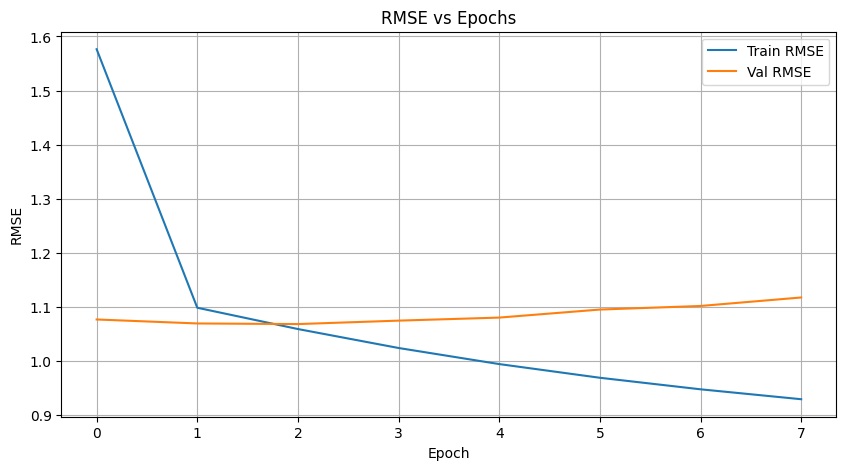

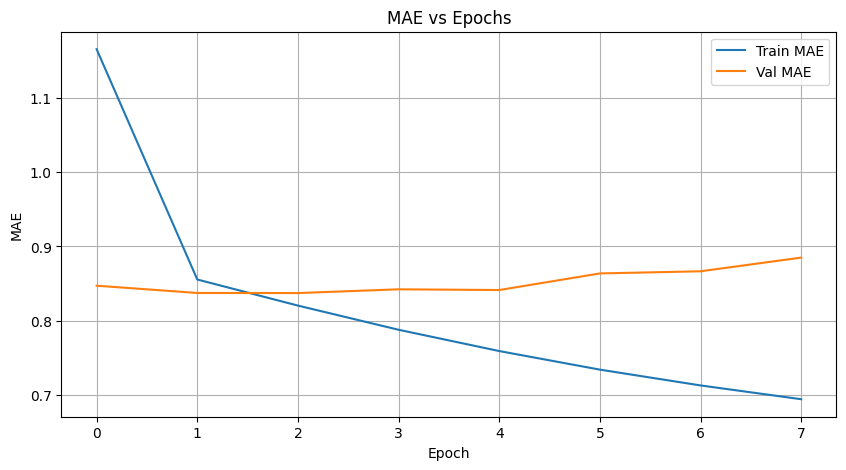

In [36]:
# SECTION 6 — Training curves

plt.figure(figsize=(10,5))
plt.plot(results["train_rmse"], label="Train RMSE")
plt.plot(results["val_rmse"], label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.title("RMSE vs Epochs")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(results["train_mae"], label="Train MAE")
plt.plot(results["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("MAE vs Epochs")
plt.grid()
plt.show()

# Temporal Matrix Factorization Model

Users: 22166 Items: 296277 Time bins: 11
Using 922267 samples

Temporal Split:
Train samples: 727400
Val samples  : 121524
Test samples : 73343
Epoch 1 | Train RMSE=1.0413, Val RMSE=1.0806
Epoch 2 | Train RMSE=0.9976, Val RMSE=1.0783
Epoch 3 | Train RMSE=0.9680, Val RMSE=1.0749
Epoch 4 | Train RMSE=0.9448, Val RMSE=1.0735
Epoch 5 | Train RMSE=0.9249, Val RMSE=1.0722
Epoch 6 | Train RMSE=0.9074, Val RMSE=1.0721
Epoch 7 | Train RMSE=0.8908, Val RMSE=1.0716
Epoch 8 | Train RMSE=0.8749, Val RMSE=1.0711
Epoch 9 | Train RMSE=0.8591, Val RMSE=1.0720
Epoch 10 | Train RMSE=0.8432, Val RMSE=1.0719
Epoch 11 | Train RMSE=0.8272, Val RMSE=1.0720
Epoch 12 | Train RMSE=0.8106, Val RMSE=1.0713
Epoch 13 | Train RMSE=0.7935, Val RMSE=1.0713
Early stopping.

TEST RMSE: 1.0569789600784243
TEST MAE : 0.8159427975173558


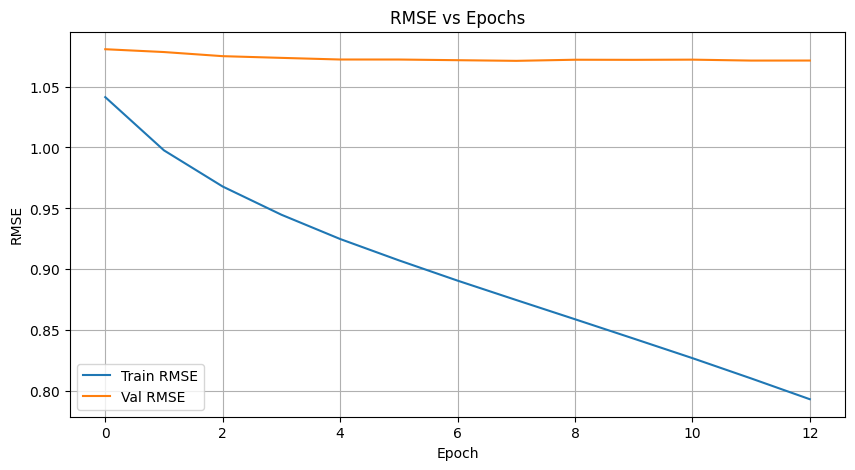

In [44]:
import numpy as np
from sklearn.metrics import mean_absolute_error
from scipy.io import loadmat
import matplotlib.pyplot as plt

# =============================================================
# 1. Load and preprocess data
# =============================================================
percent = 1.0     
batch_size = 32

data = loadmat("/kaggle/input/epinions/rating_with_timestamp.mat")
rating = data['rating']

# use only percent%
if percent < 1.0:
    N = rating.shape[0]
    keep = int(N * percent)
    idx_keep = np.random.choice(N, keep, replace=False)
    rating = rating[idx_keep]

uids = rating[:, 0].astype(int) - 1
iids = rating[:, 1].astype(int) - 1
ratings = rating[:, 3].astype(float)
times = rating[:, 5].astype(int) - 1     # assuming 1..11 → 0..10

n_users = uids.max() + 1
n_items = iids.max() + 1
n_time_bins = 11

print("Users:", n_users, "Items:", n_items, "Time bins:", n_time_bins)
print("Using %d samples" % len(rating))

X = np.column_stack([uids, iids, times])
y = ratings

# =============================================================
# 2. Temporal Split
# =============================================================
train_mask = (times <= 6)        # time bins 0–6 → original 1–7
val_mask   = (times == 7) | (times == 8)   # original 8–9
test_mask  = (times == 9) | (times == 10)  # original 10–11

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("\nTemporal Split:")
print("Train samples:", len(X_train))
print("Val samples  :", len(X_val))
print("Test samples :", len(X_test))

# =============================================================
# 3. TimeSVD++ Parameters
# =============================================================
k = 32
lr = 0.01
reg = 0.05

global_mean = y_train.mean()

bu = np.zeros(n_users)
bi = np.zeros(n_items)
bi_t = np.zeros((n_items, n_time_bins))

P = np.random.normal(0, 0.1, (n_users, k))
Q = np.random.normal(0, 0.1, (n_items, k))

alpha_u = np.zeros(n_users)

# Mean time per user
user_mean_time = np.zeros(n_users)
for u in range(n_users):
    idx = np.where(X_train[:, 0] == u)[0]
    user_mean_time[u] = X_train[idx, 2].mean() if len(idx) else 5

def dev(u, t):
    return np.sign(t - user_mean_time[u]) * (np.abs(t - user_mean_time[u]) ** 0.4)


# =============================================================
# 4. Prediction functions
# =============================================================
def predict_batch(users, items, times):
    bu_t = bu[users] + alpha_u[users] * dev(users, times)
    bi_time = bi[items] + bi_t[items, times]
    dot = np.sum(P[users] * Q[items], axis=1)
    return global_mean + bu_t + bi_time + dot

def rmse_score(X, y):
    preds = predict_batch(X[:, 0], X[:, 1], X[:, 2])
    return np.sqrt(np.mean((preds - y)**2))

def mae_score(X, y):
    preds = predict_batch(X[:, 0], X[:, 1], X[:, 2])
    return mean_absolute_error(y, preds)


# =============================================================
# 5. Training Loop
# =============================================================
best_val_rmse = 999
patience = 5
pat = 0
n_train = len(X_train)

train_rmse_list = []
val_rmse_list = []
train_mae_list = []
val_mae_list = []

for epoch in range(1000):

    perm = np.random.permutation(n_train)

    for start in range(0, n_train, batch_size):
        batch_idx = perm[start:start + batch_size]

        u = X_train[batch_idx, 0]
        i = X_train[batch_idx, 1]
        t = X_train[batch_idx, 2]
        r = y_train[batch_idx]

        pred = predict_batch(u, i, t)
        e = r - pred
        d = dev(u, t)

        bu[u] += lr * (e - reg * bu[u])
        bi[i] += lr * (e - reg * bi[i])
        bi_t[i, t] += lr * (e - reg * bi_t[i, t])
        alpha_u[u] += lr * (e * d - reg * alpha_u[u])

        Pu_old = P[u].copy()
        P[u] += lr * (e[:, None] * Q[i] - reg * P[u])
        Q[i] += lr * (e[:, None] * Pu_old - reg * Q[i])

    train_rmse = rmse_score(X_train, y_train)
    val_rmse = rmse_score(X_val, y_val)

    train_rmse_list.append(train_rmse)
    val_rmse_list.append(val_rmse)

    print(f"Epoch {epoch+1} | Train RMSE={train_rmse:.4f}, Val RMSE={val_rmse:.4f}")

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best = (bu.copy(), bi.copy(), bi_t.copy(), P.copy(), Q.copy(), alpha_u.copy())
        pat = 0
    else:
        pat += 1
        if pat >= patience:
            print("Early stopping.")
            break

bu, bi, bi_t, P, Q, alpha_u = best

# =============================================================
# 6. Final Test Evaluation
# =============================================================
test_rmse = rmse_score(X_test, y_test)
test_mae = mae_score(X_test, y_test)
print("\nTEST RMSE:", test_rmse)
print("TEST MAE :", test_mae)

# =============================================================
# 7. Plots
# =============================================================
plt.figure(figsize=(10,5))
plt.plot(train_rmse_list, label="Train RMSE")
plt.plot(val_rmse_list, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("RMSE vs Epochs")
plt.legend()
plt.grid()
plt.show()


# Temporal GraphRec Model

In [34]:
# SECTION 1 — Imports & Utilities

import os
import random
from collections import defaultdict
from typing import List, Tuple

import numpy as np
from scipy.io import loadmat
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import networkx as nx

# -------------------------
# Utilities
# -------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def rmse_mae(preds, labels):
    preds = np.array(preds, dtype=float)
    labels = np.array(labels, dtype=float)
    rmse = np.sqrt(mean_squared_error(labels, preds))
    mae = mean_absolute_error(labels, preds)
    return rmse, mae

# SECTION 2 — Data Loader with ID remapping & history building

class EpinionsLoader:
    def __init__(self, rating_mat, trust_mat, percent=1.0, seed=42, max_hist=50):
        self.rating_mat = rating_mat
        self.trust_mat = trust_mat
        self.percent = float(percent)
        self.seed = seed
        self.max_hist = int(max_hist)
        self._load_and_map()

    def _load_and_map(self):
        R = loadmat(self.rating_mat)['rating']
        T = loadmat(self.trust_mat)['trust']

        if self.percent < 1.0:
            np.random.seed(self.seed)
            idx = np.random.choice(len(R), int(len(R) * self.percent), replace=False)
            R = R[idx]

        users_from_r = np.unique(R[:, 0])
        users_from_t = np.unique(T[:, :2])
        all_users = np.unique(np.concatenate([users_from_r, users_from_t]))
        all_items = np.unique(R[:, 1])

        self.user_map = {int(orig): i for i, orig in enumerate(all_users)}
        self.item_map = {int(orig): i for i, orig in enumerate(all_items)}
        self.inv_user_map = {v: k for k, v in self.user_map.items()}
        self.inv_item_map = {v: k for k, v in self.item_map.items()}

        self.n_users = len(self.user_map)
        self.n_items = len(self.item_map)

        self.rating_records = []
        self.trust_records = []
        self.user_to_items = defaultdict(list)
        self.item_to_users = defaultdict(list)
        self.user_neighbors = defaultdict(list)

        for row in R:
            u0 = int(row[0])
            i0 = int(row[1])
            if u0 not in self.user_map or i0 not in self.item_map:
                continue

            u = self.user_map[u0]
            i = self.item_map[i0]
            rating = float(row[3])
            ts = int(row[5])

            self.rating_records.append((u, i, rating, ts))
            self.user_to_items[u].append((i, rating, ts))
            self.item_to_users[i].append((u, rating, ts))

        for row in T:
            u0 = int(row[0])
            v0 = int(row[1])
            ts = int(row[2])
            if u0 not in self.user_map or v0 not in self.user_map:
                continue

            u = self.user_map[u0]
            v = self.user_map[v0]
            self.trust_records.append((u, v, ts))
            self.user_neighbors[u].append((v, ts))

        # sort & truncate histories
        for u in range(self.n_users):
            r_hist = sorted(self.user_to_items[u], key=lambda x: x[2])
            self.user_to_items[u] = r_hist[-self.max_hist:]

            neigh = sorted(self.user_neighbors[u], key=lambda x: x[1])
            self.user_neighbors[u] = neigh[-self.max_hist:]

        for i in range(self.n_items):
            hist = sorted(self.item_to_users[i], key=lambda x: x[2])
            self.item_to_users[i] = hist[-self.max_hist:]

    def build_tensor_dataset(self):
        U, V, Rvals, Ts = [], [], [], []
        for (u, i, r, ts) in self.rating_records:
            U.append(u)
            V.append(i)
            Rvals.append(r)
            Ts.append(ts)

        return (np.array(U, dtype=np.int64),
                np.array(V, dtype=np.int64),
                np.array(Rvals, dtype=np.float32),
                np.array(Ts, dtype=np.int64))


# SECTION 3 — TemporalGraphRec model WITH USER/ITEM BIAS + ATTENTION

class ItemOpMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d * 3, d),
            nn.ReLU(),
            nn.Linear(d, d)
        )

    def forward(self, item_e, rating_e, time_e):
        x = torch.cat([item_e, rating_e, time_e], dim=-1)
        return self.mlp(x)


# ------------------------------
# Multi-head Attention Block
# ------------------------------
class SimpleAttention(nn.Module):
    def __init__(self, d, heads=4):
        super().__init__()
        self.heads = heads
        self.scale = (d // heads) ** -0.5

        self.q = nn.Linear(d, d)
        self.k = nn.Linear(d, d)
        self.v = nn.Linear(d, d)
        self.out = nn.Linear(d, d)

    def forward(self, x):
        """
        x: (H, d)
        """
        H = x.size(0)
        if H == 0:
            return torch.zeros(x.size(1), device=x.device)

        B = 1                                          # treat as batch=1
        d = x.size(1)
        h = self.heads
        dh = d // h

        q = self.q(x).view(B, H, h, dh)
        k = self.k(x).view(B, H, h, dh)
        v = self.v(x).view(B, H, h, dh)

        q = q.permute(0, 2, 1, 3)      # (B, h, H, dh)
        k = k.permute(0, 2, 3, 1)      # (B, h, dh, H)
        v = v.permute(0, 2, 1, 3)      # (B, h, H, dh)

        att = (q @ k) * self.scale     # (B, h, H, H)
        att = torch.softmax(att, dim=-1)

        out = att @ v                  # (B, h, H, dh)
        out = out.permute(0, 2, 1, 3).contiguous().view(B, H, d)  # (B,H,d)
        out = self.out(out)            # (B,H,d)
        return out.mean(dim=1).squeeze(0)  # mean over history positions


# ------------------------------
# MAIN MODEL
# ------------------------------
class TemporalGraphRecFast(nn.Module):
    def __init__(self, n_users, n_items, n_ratings=6, n_times=12, d=64, device='cpu'):
        super().__init__()
        self.device = device
        self.d = d

        # embeddings
        self.user_emb = nn.Embedding(n_users, d)
        self.item_emb = nn.Embedding(n_items, d)
        self.rating_emb = nn.Embedding(n_ratings, d)
        self.time_emb = nn.Embedding(n_times, d)

        # user & item bias (learnable)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)
        self.global_mean = nn.Parameter(torch.zeros(1))

        # attention for histories
        self.item_attention = SimpleAttention(d)
        self.social_attention = SimpleAttention(d)

        # item operator
        self.item_op_mlp = ItemOpMLP(d)

        # combine user-views
        self.user_combine = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.ReLU(),
            nn.Linear(d, d)
        )

        # final predictor
        self.predict = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.ReLU(),
            nn.Linear(d, 1)  # bias added manually
        )

        self.to(device)

    # ---------------------------------------
    # PRECOMPUTATION WITH ATTENTION
    # ---------------------------------------
    def precompute_user_item_vectors(self, loader):
        device = self.device
        out = torch.zeros((loader.n_users, self.d), device=device)

        with torch.no_grad():
            for u in range(loader.n_users):
                hist = loader.user_to_items.get(u, [])
                if len(hist) == 0:
                    continue

                item_ids = torch.tensor([i for (i, r, ts) in hist], device=device)
                rating_ids = torch.tensor([int(r) for (i, r, ts) in hist], device=device)
                time_ids = torch.tensor([ts for (i, r, ts) in hist], device=device)

                item_e = self.item_emb(item_ids)
                rating_e = self.rating_emb(rating_ids)
                time_e = self.time_emb(time_ids)

                fused = self.item_op_mlp(item_e, rating_e, time_e)  # (H,d)
                out[u] = self.item_attention(fused)

        return out

    def precompute_user_social_vectors(self, loader):
        device = self.device
        out = torch.zeros((loader.n_users, self.d), device=device)

        fuse = nn.Linear(self.d * 2, self.d).to(device)
        nn.init.xavier_uniform_(fuse.weight)

        with torch.no_grad():
            for u in range(loader.n_users):
                neigh = loader.user_neighbors.get(u, [])
                if len(neigh) == 0:
                    continue

                neigh_ids = torch.tensor([v for (v, ts) in neigh], device=device)
                time_ids = torch.tensor([ts for (v, ts) in neigh], device=device)

                ue = self.user_emb(neigh_ids)
                te = self.time_emb(time_ids)

                fused = torch.relu(fuse(torch.cat([ue, te], dim=-1)))  # (H,d)
                out[u] = self.social_attention(fused)

        return out

    # ---------------------------------------
    # FORWARD WITH BIAS TERMS
    # ---------------------------------------
    def forward(self, users, items, pre_item, pre_social):
        users = users.to(self.device)
        items = items.to(self.device)

        ui_vec = pre_item[users]
        us_vec = pre_social[users]
        ie_vec = self.item_emb(items)

        # combine user history + social context
        h_user = self.user_combine(torch.cat([ui_vec, us_vec], dim=-1))

        # main score
        out = self.predict(torch.cat([h_user, ie_vec], dim=-1)).squeeze(-1)

        # add user & item bias
        ub = self.user_bias(users).squeeze(-1)
        ib = self.item_bias(items).squeeze(-1)

        return out + ub + ib


# SECTION 4 — Training loop with metric logging

def train_fast(
    rating_mat,
    trust_mat,
    percent=1.0,
    seed=42,
    batch_size=4096,
    num_workers=2,
    max_hist=50,
    emb_dim=64,
    n_epochs=50,
    patience=5,
    lr=1e-3,
    device_str=None
):
    seed_everything(seed)

    device = torch.device(device_str if device_str else ("cuda" if torch.cuda.is_available() else "cpu"))
    print("Using device:", device)

    loader = EpinionsLoader(rating_mat, trust_mat, percent, seed, max_hist)
    U, V, R, T = loader.build_tensor_dataset()

    # TEMPORAL SPLIT — MATCH TimeSVD++
    # timestamps in dataset: 1..11 → convert to 0..10
    T0 = T - 1
    
    train_mask = (T0 <= 6)             # original time 1–7
    val_mask   = (T0 == 7) | (T0 == 8) # original time 8–9
    test_mask  = (T0 == 9) | (T0 == 10) # original time 10–11
    
    U_train, V_train, R_train = U[train_mask], V[train_mask], R[train_mask]
    U_val,   V_val,   R_val   = U[val_mask],   V[val_mask],   R[val_mask]
    U_test,  V_test,  R_test  = U[test_mask],  V[test_mask],  R[test_mask]
    
    print("Train:", len(R_train), "Val:", len(R_val), "Test:", len(R_test))


    # Torch tensors
    U_train = torch.tensor(U_train)
    V_train = torch.tensor(V_train)
    R_train = torch.tensor(R_train)

    U_val = torch.tensor(U_val)
    V_val = torch.tensor(V_val)
    R_val = torch.tensor(R_val)

    U_test = torch.tensor(U_test)
    V_test = torch.tensor(V_test)
    R_test = torch.tensor(R_test)

    model = TemporalGraphRecFast(
        loader.n_users, loader.n_items,
        n_ratings=6, n_times=12, d=emb_dim,
        device=device
    )

    model.global_mean.data.fill_(float(R_train.mean()))

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_ds = TensorDataset(U_train, V_train, R_train)
    val_ds = TensorDataset(U_val, V_val, R_val)
    test_ds = TensorDataset(U_test, V_test, R_test)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    best_val = float('inf')
    wait = 0

    # logs for plotting
    train_rmse_list, val_rmse_list, test_rmse_list = [], [], []
    train_mae_list, val_mae_list, test_mae_list = [], [], []

    for ep in range(1, n_epochs + 1):
        model.train()

        pre_item = model.precompute_user_item_vectors(loader)
        pre_social = model.precompute_user_social_vectors(loader)

        epoch_preds, epoch_labels = [], []

        for u, i, r in train_loader:
            u, i, r = u.to(device), i.to(device), r.to(device)

            opt.zero_grad()
            preds = model(u, i, pre_item, pre_social)
            loss = loss_fn(preds, r)
            loss.backward()
            opt.step()

            epoch_preds.extend(preds.detach().cpu().numpy().tolist())
            epoch_labels.extend(r.cpu().numpy().tolist())

        tr_rmse, tr_mae = rmse_mae(epoch_preds, epoch_labels)

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for u, i, r in val_loader:
                u, i = u.to(device), i.to(device)
                preds = model(u, i, pre_item, pre_social)
                val_preds.extend(preds.cpu().numpy().tolist())
                val_labels.extend(r.numpy().tolist())

        v_rmse, v_mae = rmse_mae(val_preds, val_labels)

        print(f"Epoch {ep} | Train RMSE={tr_rmse:.4f} | Val RMSE={v_rmse:.4f}")

        train_rmse_list.append(tr_rmse)
        train_mae_list.append(tr_mae)
        val_rmse_list.append(v_rmse)
        val_mae_list.append(v_mae)

        # early stopping
        if v_rmse < best_val - 1e-5:
            best_val = v_rmse
            wait = 0
            torch.save(model.state_dict(), "best_fast_graphrec.pth")
        else:
            wait += 1
            if wait >= patience:
                break

    # Load best
    model.load_state_dict(torch.load("best_fast_graphrec.pth", map_location=device))

    # Final test evaluation
    pre_item = model.precompute_user_item_vectors(loader)
    pre_social = model.precompute_user_social_vectors(loader)

    test_preds, test_labels = [], []
    with torch.no_grad():
        for u, i, r in test_loader:
            u, i = u.to(device), i.to(device)
            preds = model(u, i, pre_item, pre_social)
            test_preds.extend(preds.cpu().numpy().tolist())
            test_labels.extend(r.numpy().tolist())

    te_rmse, te_mae = rmse_mae(test_preds, test_labels)
    print("TEST RMSE:", te_rmse, "TEST MAE:", te_mae)

    test_rmse_list.append(te_rmse)
    test_mae_list.append(te_mae)

    # return everything needed for plots
    return {
        "model": model,
        "loader": loader,
        "train_rmse": train_rmse_list,
        "val_rmse": val_rmse_list,
        "test_rmse": test_rmse_list,
        "train_mae": train_mae_list,
        "val_mae": val_mae_list,
        "test_mae": test_mae_list,
    }


# SECTION 5 — Train the model

results = train_fast(
    rating_mat="/kaggle/input/epinions/rating_with_timestamp.mat",
    trust_mat="/kaggle/input/epinions/epinion_trust_with_timestamp.mat",
    percent=1.0,
    seed=42,
    batch_size=4096,
    num_workers=0,
    max_hist=50,
    emb_dim=128,
    n_epochs=50,
    patience=5,
    lr=1e-3,
)

Using device: cuda
Train: 727400 Val: 121524 Test: 73343
Epoch 1 | Train RMSE=1.5763 | Val RMSE=1.0771
Epoch 2 | Train RMSE=1.0988 | Val RMSE=1.0698
Epoch 3 | Train RMSE=1.0595 | Val RMSE=1.0686
Epoch 4 | Train RMSE=1.0244 | Val RMSE=1.0750
Epoch 5 | Train RMSE=0.9947 | Val RMSE=1.0806
Epoch 6 | Train RMSE=0.9695 | Val RMSE=1.0955
Epoch 7 | Train RMSE=0.9481 | Val RMSE=1.1021
Epoch 8 | Train RMSE=0.9298 | Val RMSE=1.1178
TEST RMSE: 1.0386523416670588 TEST MAE: 0.8012747691348366


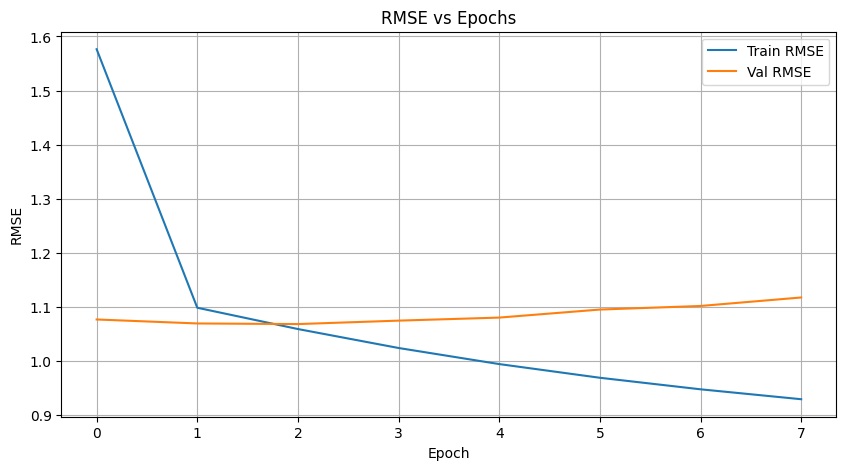

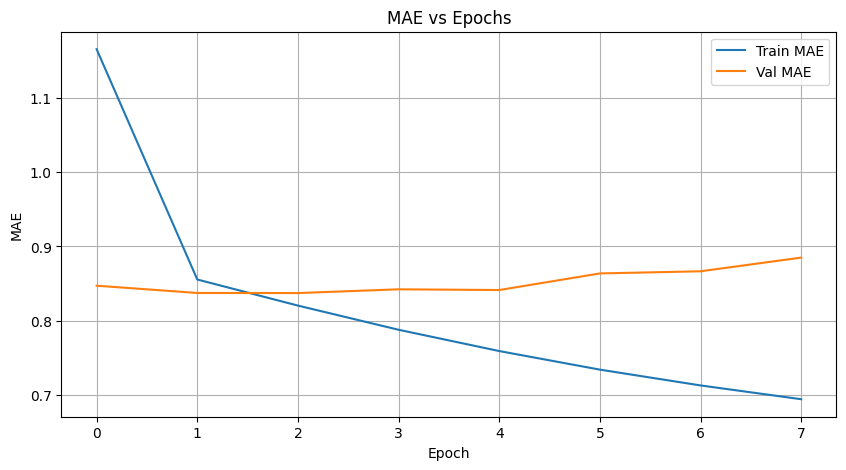

In [35]:
# SECTION 6 — Training curves

plt.figure(figsize=(10,5))
plt.plot(results["train_rmse"], label="Train RMSE")
plt.plot(results["val_rmse"], label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.title("RMSE vs Epochs")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(results["train_mae"], label="Train MAE")
plt.plot(results["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("MAE vs Epochs")
plt.grid()
plt.show()